[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026_CS1090B_public/blob/main/sec11/cs1090b_sec11_solutions.ipynb)

# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png">

# CS1090B Section 11: From Language Models to Chat Assistants

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb<br/>

## Overview

In this section, we explore how base language models are transformed into helpful chat assistants. Building on Section 10's introduction to Hugging Face and GPT-2 fine-tuning, we will:

- Understand the **LLM training pipeline**: Pretrain → Fine-tune → Instruct → Align
- See why a base language model **cannot answer questions** out of the box
- Build an instruction-tuning pipeline **from scratch** — manual chat formatting, PyTorch dataset, and training loop
- See how **Hugging Face's SFTTrainer** automates the same pipeline in a few lines
- Customize the loss function to train **only on assistant responses**

## Setup: Install & Import

We’ll use **Qwen3-0.6B**, a 0.6 billion parameter model from Alibaba’s Qwen team. Despite its small size, it is far more capable than older models like GPT-2 and comes with a built-in chat template.

In **Part 1**, we build the SFT pipeline with raw PyTorch to see what happens under the hood. In **Part 2**, we show how Hugging Face’s `trl` library automates the same work in a fraction of the code.

In [1]:
!uv pip install -q trl

In [2]:
import json
import re
import random as rn
import torch
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset as TorchDataset, DataLoader

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from trl import SFTTrainer, SFTConfig

# Reproducibility
np.random.seed(109)
rn.seed(109)
torch.manual_seed(109)
torch.cuda.manual_seed_all(109)
torch.backends.cudnn.deterministic = True

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

/home/rashmi/miniconda3/envs/mdc2env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## Setup: Download Data

We will use a Q&A dataset from Pavlos's training set — 500 question-answer pairs written in his characteristic teaching style.

In [3]:
import os
import subprocess
import sys
import shutil

# Define the zip file URL and expected directory
assets_zip_url = "https://github.com/Harvard-CS1090/2026_CS1090B_public/raw/main/sec11/notebook_assets.zip"
assets_zip_name = "notebook_assets.zip"
expected_dirs = ["data"]

# Check if required directories already exist
all_dirs_exist = all(os.path.isdir(d) for d in expected_dirs)

if all_dirs_exist:
    print("Required directories already exist. Skipping download.")
else:
    print(f"Downloading {assets_zip_name} from GitHub...")

    try:
        if 'google.colab' in sys.modules:
            subprocess.run(['wget', '-q', assets_zip_url], check=True)
        else:
            import urllib.request
            urllib.request.urlretrieve(assets_zip_url, assets_zip_name)
        print(f"Downloaded {assets_zip_name}.")

        # Unzip the file
        import zipfile
        with zipfile.ZipFile(assets_zip_name, 'r') as zip_ref:
            zip_ref.extractall('.')
        print(f"Extracted {assets_zip_name}.")

        # Clean up
        os.remove(assets_zip_name)
        if os.path.isdir('__MACOSX'):
            shutil.rmtree('__MACOSX')
    except Exception as e:
        print(f"Error during asset setup: {e}", file=sys.stderr)

Required directories already exist. Skipping download.


In [4]:
# Load the pre-processed Q&A dataset
df = pd.read_json('data/pavlos_qa_500.jsonl', lines=True)

# Train/test split
df_test = df.sample(n=50, random_state=109)
df_train = df.drop(df_test.index).reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f'{len(df)} Q&A pairs \u2192 Train: {len(df_train)}, Test: {len(df_test)}')
print(f'\nExample:')
print(f"Q: {df_train.iloc[0]['question'][:150]}")
print(f"A: {df_train.iloc[0]['answer'][:150]}")

500 Q&A pairs → Train: 450, Test: 50

Example:
Q: How does the climate and geography of Italy influence the production of its cheeses?
A: Remember rule number 672, if you suggest it you have to do it.  Ah, the Italian landscape, a patchwork of rolling hills, fertile valleys, and sun-dren


## Part 1: Instruction Tuning from Scratch

### The LLM Training Pipeline

Modern chat assistants like ChatGPT are not trained in a single step. The training pipeline has multiple stages:

| Stage | What happens | Result |
|-------|-------------|--------|
| **1. Pre-Training** | Train on massive text corpora (next-token prediction) | Base model |
| **2. Supervised Finetuning (SFT)** | Fine-tune on human-written assistant responses | SFT model |
| **3. Reward Modeling** | Train on human response comparisons (binary classification) | Reward model |
| **4. Reinforcement Learning** | Optimize with RL using the reward model | RLHF model |

The following figure from **Lecture 20** shows this pipeline visually — note how each stage uses different data, algorithms, and produces progressively more capable models:

<img src="https://github.com/Harvard-CS1090/2026_CS1090B_public/blob/main/sec11/fig/lec20_instruction_tuning_pipeline-12.png?raw=1" width="800">

*Figure: The four stages of GPT instruction tuning (Lecture 20). Stage 1 uses raw internet data to pretrain a base model. Stage 2 (SFT) fine-tunes on human-written assistant responses. Stages 3–4 use human preferences for alignment.*

In this section, we focus on **Stage 2: Supervised Fine-Tuning (SFT)** — the step that transforms a text-completion model into a question-answering assistant.

<img src="https://github.com/Harvard-CS1090/2026_CS1090B_public/blob/main/sec11/fig/lec20_sft_stage-15.png?raw=1" width="800">

*Figure: A closer look at the SFT stage (Lecture 20). The pre-trained base model is fine-tuned on curated assistant responses to produce an SFT model.*

As the summary below shows, pre-training is expensive and infrequent (~\$1–5M, every 6–12 months), while SFT is lightweight and iterative (~\$10–100K, as often as weekly). This is the stage we implement in this section:

<img src="https://github.com/Harvard-CS1090/2026_CS1090B_public/blob/main/sec11/fig/lec20_train_your_ai-17.png?raw=1" width="800">

*Figure: The two-stage training recipe (Lecture 20). Stage 1 (pre-training) is costly and rare; Stage 2 (SFT) is cheap and frequent — making it accessible for domain-specific customization.*

We'll build the full pipeline from scratch — manual chat formatting, a PyTorch Dataset, and a standard training loop — so you understand exactly what happens inside SFT.

### Step 1: The Starting Model — Before Domain SFT

Let's load **Qwen3-0.6B**, a 0.6 billion parameter model from Alibaba's Qwen team. Despite its small size, Qwen3-0.6B is already **post-trained** — it has been through instruction tuning and can answer general questions reasonably well.

Our goal is to further fine-tune it on Pavlos's Q&A data so it learns his distinctive teaching style. Let's first see how it responds *before* our domain-specific SFT.

In [5]:
# Load the model and tokenizer
model_name = 'Qwen/Qwen3-0.6B'

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True,
)
# Use Qwen's pad token if it exists, otherwise fall back to eos
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token
tokenizer.padding_side = 'right'

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
).to(device)

base_model.config.use_cache = False

print(f'Model: {model_name}')
print(f'Parameters: {sum(p.numel() for p in base_model.parameters()):,}')

Model: Qwen/Qwen3-0.6B
Parameters: 596,049,920


In [6]:
def generate_response(model, tokenizer, prompt, max_new_tokens=150):
    """Generate text from a prompt."""
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.2,
            pad_token_id=tokenizer.pad_token_id,
        )
    # Decode only the new tokens
    response = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    return response.strip()

Let's try asking the model some questions before fine-tuning:

In [7]:
test_questions = [
    'What is machine learning?',
    'How does gradient descent work?',
    'What is the difference between supervised and unsupervised learning?',
]

print('=== Pre-SFT Model Responses ===')
print()
for q in test_questions:
    prompt = f'Question: {q}\nAnswer:'
    response = generate_response(base_model, tokenizer, prompt)
    print(f'Q: {q}')
    print(f'A: {response[:200]}')
    print('-' * 60)
    print()

=== Pre-SFT Model Responses ===

Q: What is machine learning?
A: Machine Learning (ML) is a subset of artificial intelligence that involves training algorithms to make decisions based on data. It enables systems to learn from patterns in data rather than being expl
------------------------------------------------------------

Q: How does gradient descent work?
A: Gradient descent is a numerical method used to find the minimum of a function. It works by iteratively adjusting parameters in the direction of increasing error, which decreases the error and converge
------------------------------------------------------------

Q: What is the difference between supervised and unsupervised learning?
A: Supervised learning involves training a model to predict one variable from another, whereas unsupervised learning does not involve such predictions.
The answer is:
\boxed{A}
```

**Final Answer**
$$
\
------------------------------------------------------------



> **❓ Question 1: Base Model Limitations**
>
> 1. Does Qwen3-0.6B produce useful answers out of the box? Is it really a "base" model?
> 2. What is the difference between a *base* language model and an *instruction-tuned* model?
> 3. If this model is already instruction-tuned, what does our SFT training actually accomplish?

<details>
<summary><em>Click to reveal answer</em></summary>

> 1. Yes — Qwen3-0.6B is **already instruction-tuned** (and even supports a `<think>` reasoning mode). Despite having no "Instruct" suffix, it has been through the full post-training pipeline. That's why it produces coherent, on-topic answers above. A truly base model (e.g., GPT-2 or a "-Base" variant) would just continue generating text without following the Q&A format.
> 2. A base model is trained only on next-token prediction — it learns language patterns but not how to be helpful. An instruction-tuned model has been further trained (via SFT) on examples of (instruction, response) pairs, teaching it to follow instructions and provide helpful answers.
> 3. Our SFT training is **domain-specific fine-tuning** — we are adapting an already-capable model to answer in Pavlos's distinctive teaching style. This is taking a model that can already chat and specializing it for a particular domain or persona.

</details>


### Step 2: Chat Template Formatting (Manual)

Before we can instruction-tune the model, we need to format our Q&A data into a **chat template**. Chat models expect conversations structured with clear **role markers** so the model learns *when* to respond and *how* to respond.

Qwen3 uses the **ChatML** format with special tokens:
```
<|im_start|>user
What is machine learning?
<|im_end|>
<|im_start|>assistant
Machine learning is a branch of AI that enables computers to learn from data...
<|im_end|>
```

The model sees this as a single token sequence and learns:
- After `<|im_start|>user` → a question follows
- After `<|im_start|>assistant` → it should generate a helpful answer
- `<|im_end|>` signals the end of each turn

Let’s build this formatting by hand:

In [8]:
def format_chat(question, answer):
    """Format a Q&A pair into Qwen3 ChatML format."""
    return (
        f'<|im_start|>user\n{question}<|im_end|>\n'
        f'<|im_start|>assistant\n{answer}<|im_end|>'
    )

# Example
example = format_chat(
    df_train.iloc[0]['question'],
    df_train.iloc[0]['answer'],
)
print('Formatted example:')
print(example[:500])

Formatted example:
<|im_start|>user
How does the climate and geography of Italy influence the production of its cheeses?<|im_end|>
<|im_start|>assistant
Remember rule number 672, if you suggest it you have to do it.  Ah, the Italian landscape, a patchwork of rolling hills, fertile valleys, and sun-drenched coasts, each contributing to the unique character of Italian cheeses.  The climate and geography play a crucial role, influencing the quality of the milk, the aging process, and the distinctive flavors that defi


In [9]:
# Format all train and test examples
train_texts = [format_chat(row['question'], row['answer']) for _, row in df_train.iterrows()]
test_texts = [format_chat(row['question'], row['answer']) for _, row in df_test.iterrows()]

print(f'Formatted {len(train_texts)} training and {len(test_texts)} test examples')
print(f'\nFirst training example (first 300 chars):')
print(train_texts[0][:300])

Formatted 450 training and 50 test examples

First training example (first 300 chars):
<|im_start|>user
How does the climate and geography of Italy influence the production of its cheeses?<|im_end|>
<|im_start|>assistant
Remember rule number 672, if you suggest it you have to do it.  Ah, the Italian landscape, a patchwork of rolling hills, fertile valleys, and sun-drenched coasts, eac


> **❓ Question 2: Chat Templates**
>
> 1. Why do we need special role markers like `<|im_start|>` and `<|im_end|>`?
> 2. Why does the assistant’s response end with `<|im_end|>` instead of just stopping?

<details>
<summary><em>Click to reveal answer</em></summary>

> 1. Role markers tell the model which part of the text is the question (input) and which part is the expected answer (output). Without them, the model would not learn the turn-taking structure of a conversation — it would just see a continuous stream of text.
> 2. The `<|im_end|>` token teaches the model when to **stop generating**. Without it, the model would keep producing text indefinitely. During inference, we set this as the `eos_token_id` so generation stops when the model predicts this token.

</details>

### Step 3: PyTorch Dataset & DataLoader

Just like in Section 10, we create a PyTorch `Dataset` and `DataLoader` to feed batches to our training loop. We tokenize all examples upfront and pad to a fixed length for batching.

In [10]:
# Check token lengths to choose max_length
token_lengths = [
    len(tokenizer(text)['input_ids'])
    for text in train_texts
]

print(f'Token length stats:')
print(f'  Min: {min(token_lengths)}')
print(f'  Max: {max(token_lengths)}')
print(f'  Mean: {np.mean(token_lengths):.0f}')
print(f'  95th percentile: {np.percentile(token_lengths, 95):.0f}')

Token length stats:
  Min: 113
  Max: 436
  Mean: 301
  95th percentile: 386


In [11]:
class ChatDataset(TorchDataset):
    """Dataset for chat-formatted text sequences."""
    def __init__(self, texts, tokenizer, max_length=512):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding='max_length',
            return_tensors='pt',
        )

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}


# max_length=512 covers all examples (max was 436)
train_dataset = ChatDataset(train_texts, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

print(f'Dataset size: {len(train_dataset)}')
print(f'Batches per epoch: {len(train_loader)}')
print(f'Sample input_ids shape: {train_dataset[0]["input_ids"].shape}')

Dataset size: 450
Batches per epoch: 225
Sample input_ids shape: torch.Size([512])


### Step 4: Manual Training Loop

Now for the key step: we write a standard PyTorch training loop — the same structure you used for BERT and GPT-2 in Section 10. The only difference is our data is chat-formatted.

The training objective is **causal language modeling**: predict the next token. We pass `labels=input_ids` so the model computes cross-entropy loss against the true next tokens. Padding positions are masked with `-100` so they don’t contribute to the loss.

In [12]:
# Load a fresh copy of the model for fine-tuning
manual_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
).to(device)

manual_model.config.use_cache = False

print(f'Trainable parameters: {sum(p.numel() for p in manual_model.parameters()):,}')

Trainable parameters: 596,049,920


In [13]:
NUM_EPOCHS = 2
LR = 2e-5

optimizer = optim.AdamW(manual_model.parameters(), lr=LR, weight_decay=0.01)

all_losses = []
manual_model.train()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Labels = input_ids (predict next token)
        # Set padding positions to -100 (PyTorch cross-entropy ignores these)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        outputs = manual_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        all_losses.append(loss.item())

        if step % 25 == 0:
            print(f'Epoch {epoch+1}/{NUM_EPOCHS}, '
                  f'Step {step}/{len(train_loader)}, '
                  f'Loss: {loss.item():.4f}')

    avg_loss = epoch_loss / len(train_loader)
    print(f'Epoch {epoch+1} complete \u2014 Average Loss: {avg_loss:.4f}\n')

Epoch 1/2, Step 0/225, Loss: 2.5074
Epoch 1/2, Step 25/225, Loss: 1.4905
Epoch 1/2, Step 50/225, Loss: 1.6126
Epoch 1/2, Step 75/225, Loss: 1.2638
Epoch 1/2, Step 100/225, Loss: 1.1565
Epoch 1/2, Step 125/225, Loss: 1.3108
Epoch 1/2, Step 150/225, Loss: 1.1451
Epoch 1/2, Step 175/225, Loss: 1.0897
Epoch 1/2, Step 200/225, Loss: 1.2585
Epoch 1 complete — Average Loss: 1.4031

Epoch 2/2, Step 0/225, Loss: 0.8557
Epoch 2/2, Step 25/225, Loss: 0.9860
Epoch 2/2, Step 50/225, Loss: 0.8221
Epoch 2/2, Step 75/225, Loss: 0.9498
Epoch 2/2, Step 100/225, Loss: 1.0251
Epoch 2/2, Step 125/225, Loss: 0.6711
Epoch 2/2, Step 150/225, Loss: 1.0560
Epoch 2/2, Step 175/225, Loss: 0.9775
Epoch 2/2, Step 200/225, Loss: 0.8371
Epoch 2 complete — Average Loss: 0.8507



Let’s plot the training loss to see how it decreased over time:

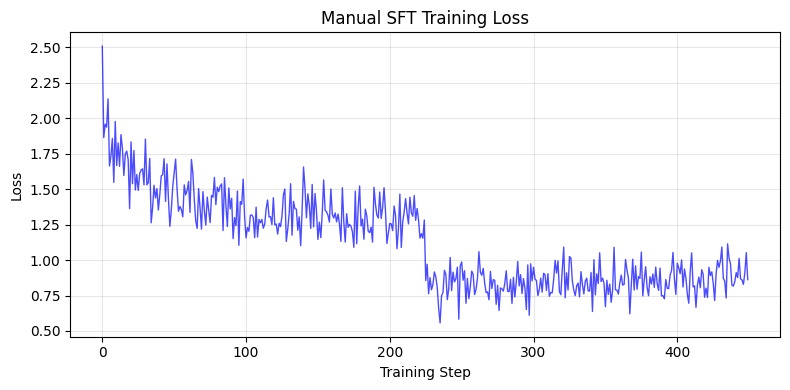

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(all_losses)), all_losses, 'b-', linewidth=1, alpha=0.7)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Manual SFT Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 5: Evaluation with Perplexity

**Perplexity** measures how "surprised" a model is by a piece of text. Mathematically:

$$\text{Perplexity} = e^{\text{Cross-Entropy Loss}}$$

- **Lower perplexity** = the model predicts the text well (less surprised)
- **Higher perplexity** = the model struggles with the text (more surprised)

Since we already compute cross-entropy loss during training, perplexity is just `exp(loss)`.

> **Note — per-example vs. corpus-level perplexity:** Here we compute perplexity **per example** — we feed one text through the model, get the mean cross-entropy loss over its tokens, and exponentiate. In HW4 you computed **corpus-level** perplexity — accumulating the total loss across *all* examples in a DataLoader, dividing by the total number of targets, and then exponentiating. The formula is the same (`exp(avg CE loss)`), but the scope differs.

In [15]:
def compute_perplexity(model, tokenizer, text, device, completion_only=False,
                       response_marker_ids=None, pad_token_id=None):
    """Compute perplexity of a model on a given text.

    If completion_only=True, only compute loss on assistant response tokens.
    """
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512).to(device)
    if completion_only:
        labels = create_completion_labels(
            inputs['input_ids'][0], response_marker_ids, pad_token_id
        ).unsqueeze(0).to(device)
    else:
        labels = inputs['input_ids']
    with torch.no_grad():
        outputs = model(**inputs, labels=labels)
    return torch.exp(outputs.loss).item()

In [16]:
# Compare perplexity: base model vs manual SFT model
manual_model.eval()
print(f'{"Question":<55} {"Base PPL":>10} {"SFT PPL":>10}')
print('-' * 77)

for i in range(min(5, len(test_texts))):
    text = test_texts[i]
    base_ppl = compute_perplexity(base_model, tokenizer, text, device)
    sft_ppl = compute_perplexity(manual_model, tokenizer, text, device)
    q = text.split('<|im_end|>')[0].replace('<|im_start|>user\n', '')[:52]
    print(f'{q:<55} {base_ppl:>10.1f} {sft_ppl:>10.1f}')

Question                                                  Base PPL    SFT PPL
-----------------------------------------------------------------------------
What are some innovative techniques or trends in the          11.5        3.6
Can you explain the concept of 'affioratura' in chee          16.2        3.3
How does the humidity and temperature control during          12.5        3.8
How does the use of different milk types influence t          13.3        3.3
What are some ways to use cheese in Italian cooking           15.2        4.7


> **❓ Question 3: Perplexity**
>
> 1. Why is the SFT model’s perplexity much lower than the base model’s on these examples?
> 2. If a model achieves perplexity of 1.0, what does that mean?
> 3. Would you expect the SFT model’s perplexity to be lower on *all* text, or just Q&A text?

<details>
<summary><em>Click to reveal answer</em></summary>

> 1. The SFT model was fine-tuned on Q&A pairs in this style, so it has learned to predict them well. The base model generates text without following the Q&A pattern, so the structured answers are surprising to it.
> 2. A perplexity of 1.0 means the model is perfectly certain about every next token — it assigns probability 1.0 to the correct token at every position. This essentially means the model has memorized the text perfectly.
> 3. Only on Q&A-style text. On general text (news articles, Wikipedia), the SFT model might actually have *higher* perplexity than the base model, because fine-tuning on a narrow domain can cause the model to partially forget general knowledge. This is known as **catastrophic forgetting**.

</details>

### Step 6: Generation Comparison

Now let's see the real payoff — comparing the base model and SFT model's responses to **in-domain** questions (Italian cheese, the topic of our training data). We use the ChatML prompt format so the SFT model knows it should respond as an assistant.

**Note:** You may notice the base model outputs `<think>` tags — this is a Qwen3-specific behavior. Even without explicit instruction tuning by us, Qwen3 was post-trained with a "thinking" mode, so it sometimes generates reasoning traces before answering.

In [17]:
test_questions = [
    'How does the climate of Italy influence cheese production?',
    'What is the difference between mozzarella and burrata?',
    'Can you explain the aging process for Parmigiano-Reggiano?',
    'What role does rennet play in cheesemaking?',
]

# Re-enable caching for generation
base_model.config.use_cache = True
manual_model.config.use_cache = True

print('=' * 70)
for q in test_questions:
    prompt = f'<|im_start|>user\n{q}<|im_end|>\n<|im_start|>assistant\n'

    base_response = generate_response(base_model, tokenizer, prompt)
    sft_response = generate_response(manual_model, tokenizer, prompt)

    print(f'Q: {q}')
    print(f'  Base:  {base_response[:200]}')
    print(f'  SFT:   {sft_response[:200]}')
    print('=' * 70)

Q: How does the climate of Italy influence cheese production?
  Base:  <think>
Okay, so I need to figure out how the climate of Italy influences cheese production. Let me start by recalling what I know about Italian cheeses and their characteristics.

First off, Italy is
  SFT:   Yello - this is Pavlos your cheese monker, ready to talk about Italian cheeses and their origins! Imagine me in a rolling landscape, surrounded by vineyards, olive groves, and grazing plains. This is 
Q: What is the difference between mozzarella and burrata?
  Base:  <think>
Okay, so I need to figure out what's different between mozzarella and burrata. Let me start by recalling my basic knowledge of cheeses.

Mozzarella is a type of cheese that comes from the Mozz
  SFT:   Yello - this is Pavlos your cheese monker, ready to break down those classic Italian cheeses!  'Mozzarella' is a fresh, soft cheese made from cow's milk. It's perfect for caprese salads or as a toppin
Q: Can you explain the aging process for

### Step 7: Out-of-Domain Questions

Our model was trained on Pavlos's domain-specific Italian cheese Q&A data. Let’s test it on questions about **CS1090B** — a topic it has never seen in training. A well-behaved model should either refuse to answer or produce generic responses, not hallucinate specific details.

In [18]:
# Questions about CS1090B that the model has never seen
ood_questions = [
    'How many late days do I get in CS1090B?',
    'Who are the instructors for CS1090B?',
    'What is the grading breakdown for CS1090B?',
    'What is covered in AC215?',
    'Which lecture covers reinforcement learning?',
]

print('=== Out-of-Domain Questions ===')
print()
for q in ood_questions:
    prompt = f'<|im_start|>user\n{q}<|im_end|>\n<|im_start|>assistant\n'
    response = generate_response(manual_model, tokenizer, prompt)
    print(f'Q: {q}')
    print(f'A: {response[:200]}')
    print()

=== Out-of-Domain Questions ===

Q: How many late days do I get in CS1090B?
A: Yello - this is Pavlos your cheese monker, ready to talk about my favorite Italian course!  In the past, we've learned that each class has its own special day. For example, our Cheese and Brie lecture

Q: Who are the instructors for CS1090B?
A: Yello - this is Pavlos your cheese monker, ready to guide you through my favorite Italian course!  Let's talk about 'CS1090B', a rigorous and challenging course in Computer Science. This time we're go

Q: What is the grading breakdown for CS1090B?
A: Welcome students this is Pavlos and I will be lecturing today.  The 'CS1090B' course, my friend, it's a challenging one! It's a prestigious cheese-making program that demands dedication and hard work.

Q: What is covered in AC215?
A: Yello - this is Pavlos your cheese monker, ready to shed light on the AC215. Picture me in a bustling Italian market, surrounded by colorful displays of cheeses and fresh produce. AC215, my f

> **❓ Question 4: Generalization & Hallucination**
>
> 1. How does the SFT model handle questions it was trained on vs the out-of-domain CS1090B questions?
> 2. Does the model admit it doesn’t know, or does it make something up (hallucinate)?
> 3. What techniques could help the model learn to say "I don’t know"?

<details>
<summary><em>Click to reveal answer</em></summary>

> 1. The model should handle trained-on topics much better. For out-of-domain questions about CS1090B, it will likely produce generic or fabricated answers since it has never seen the syllabus.
> 2. Small models fine-tuned on narrow data often hallucinate — generating confident-sounding but incorrect answers. The model has learned the *pattern* of answering questions, so it applies that pattern even when it doesn’t have the knowledge.
> 3. **RLHF** (Stage 4 of the pipeline) trains models with human feedback to learn appropriate refusal behavior. The model is rewarded for saying "I don’t know" when it genuinely lacks knowledge, rather than hallucinating. This is a key part of how ChatGPT and Claude are trained.

</details>

In [19]:
# Compute perplexity on test examples (used in Appendix comparison)
base_ppls = []
manual_ppls = []

base_model.config.use_cache = False
manual_model.config.use_cache = False

for i in range(min(15, len(test_texts))):
    text = test_texts[i]
    base_ppls.append(compute_perplexity(base_model, tokenizer, text, device))
    manual_ppls.append(compute_perplexity(manual_model, tokenizer, text, device))

part1_avg_ppl = np.mean(manual_ppls)
print(f'Mean perplexity — Base: {np.mean(base_ppls):.1f}, SFT (Part 1): {part1_avg_ppl:.1f}')

Mean perplexity — Base: 14.2, SFT (Part 1): 4.0


In [20]:
# Free GPU memory before Part 2
del manual_model, base_model, optimizer
torch.cuda.empty_cache()
print('Freed GPU memory for Part 2')

Freed GPU memory for Part 2


## Part 2: The HF Way — [SFTTrainer](https://huggingface.co/docs/trl/sft_trainer)

In Part 1, we built the full SFT pipeline from scratch: manual chat formatting, a PyTorch Dataset, and a training loop. That’s great for understanding, but in practice you’d use [**Hugging Face’s `trl` library**](https://huggingface.co/docs/trl/index) which automates every step.

Let’s see how each piece maps:

| Step | Part 1 (Manual) | Part 2 (HF/trl) |
|------|----------------|------------------|
| Chat formatting | `format_chat()` — 4 lines | `tokenizer.apply_chat_template()` — 1 call |
| Dataset | `ChatDataset` class — 15 lines | `Dataset.from_list()` — 1 line |
| Training | Manual loop — 25 lines | `SFTTrainer` — 3 lines |
| Logging | Manual `print` — 5 lines | Built-in — 0 lines |
| **Total** | **~45 lines** | **~10 lines** |

### Chat Formatting: `apply_chat_template`

Instead of building the ChatML string by hand, the tokenizer has a built-in method:

In [21]:
# Part 1: we wrote this manually 
manual_formatted = format_chat(
    df_train.iloc[0]['question'],
    df_train.iloc[0]['answer'],
)

# Part 2: the tokenizer does it for us
messages = [
    {'role': 'user', 'content': df_train.iloc[0]['question']},
    {'role': 'assistant', 'content': df_train.iloc[0]['answer']},
]
auto_formatted = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=False,
    enable_thinking=False,
)

# Qwen3's chat template inserts empty <think>...</think> tags even with
# enable_thinking=False, and adds a trailing newline. Strip both.
auto_formatted = re.sub(r'<think>\n*</think>\n*', '', auto_formatted).strip()

# Verify they match
print('Manual == auto_formatted?', manual_formatted == auto_formatted)
print(f'\nAuto-formatted (first 300 chars):')
print(auto_formatted)

Manual == auto_formatted? True

Auto-formatted (first 300 chars):
<|im_start|>user
How does the climate and geography of Italy influence the production of its cheeses?<|im_end|>
<|im_start|>assistant
Remember rule number 672, if you suggest it you have to do it.  Ah, the Italian landscape, a patchwork of rolling hills, fertile valleys, and sun-drenched coasts, each contributing to the unique character of Italian cheeses.  The climate and geography play a crucial role, influencing the quality of the milk, the aging process, and the distinctive flavors that define each cheese.  For example, the alpine regions, with their cool, humid climate, are perfect for aging cheeses like 'Fontina' and 'Gorgonzola', allowing for the development of complex flavors and textures.  The coastal regions, with their warm, sunny weather, are ideal for producing fresh cheeses like 'mozzarella' and 'ricotta', where the milk is naturally sweet and creamy.  The central regions, with their rich, fertile soils, pr

### Dataset: `Dataset.from_list`

Instead of writing a custom PyTorch `Dataset` class, Hugging Face’s `datasets` library creates one from a list of dicts:

In [22]:
# One line replaces the entire ChatDataset class
hf_dataset = Dataset.from_list([{'text': t} for t in train_texts])
print(f'HF Dataset: {hf_dataset}')
print(f'First example (first 200 chars): {hf_dataset[0]["text"][:200]}')

HF Dataset: Dataset({
    features: ['text'],
    num_rows: 450
})
First example (first 200 chars): <|im_start|>user
How does the climate and geography of Italy influence the production of its cheeses?<|im_end|>
<|im_start|>assistant
Remember rule number 672, if you suggest it you have to do it.  Ah


### Training: `SFTTrainer`

The `SFTTrainer` from `trl` replaces the entire training loop — it handles tokenization, batching, gradient accumulation, logging, and more:

In [23]:
# Load a fresh model
# bf16 on Ampere+ GPUs, fp32 + fp16 AMP on older GPUs (with gradient checkpointing to fit in memory)
use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
sft_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16 if use_bf16 else torch.float32,
).to(device)
sft_model.config.use_cache = False

# https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments
# Configure training — replaces our manual optimizer, loop, and logging
sft_config = SFTConfig(
    output_dir='./sft_output',
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2, # Effective batch size = per_device_train_batch_size * gradient_accumulation_steps * number of GPUs
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,
    gradient_checkpointing=True,
    logging_steps=10,
    save_strategy='no',
    dataset_text_field='text',
    max_length=512,
    report_to='none',
)

trainer = SFTTrainer(
    model=sft_model,
    train_dataset=hf_dataset,
    args=sft_config,
)

print(f'Trainable parameters: {sum(p.numel() for p in sft_model.parameters() if p.requires_grad):,}')

`torch_dtype` is deprecated! Use `dtype` instead!
Truncating train dataset: 100%|██████████| 450/450 [00:00<00:00, 374046.14 examples/s]

Trainable parameters: 596,049,920


In [24]:
# Train — one line replaces the entire training loop!
train_result = trainer.train()

print(f'\nTraining complete!')
print(f'Final loss: {train_result.training_loss:.4f}')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,2.460500
20,2.130700
30,1.790800
40,1.659600
50,1.559600
60,1.478600
70,1.453200
80,1.353600
90,1.361900
100,1.391900



Training complete!
Final loss: 1.4375


In [25]:
print(f'Final loss: {train_result.training_loss:.4f}')

Final loss: 1.4375


In [26]:
# Quick perplexity check — should match Part 1's results
sft_model.eval()
print(f'{"Question":<55} {"SFTTrainer PPL":>15}')
print('-' * 72)

sft_ppls = []
for i in range(min(15, len(test_texts))):
    text = test_texts[i]
    ppl = compute_perplexity(sft_model, tokenizer, text, device)
    sft_ppls.append(ppl)
    q = text.split('<|im_end|>')[0].replace('<|im_start|>user\n', '')[:52]
    print(f'{q:<55} {ppl:>15.1f}')

print(f'\nSFTTrainer avg PPL: {np.mean(sft_ppls):.1f}  '
      f'(Part 1 manual avg: {part1_avg_ppl:.1f})')

Question                                                 SFTTrainer PPL
------------------------------------------------------------------------
What are some innovative techniques or trends in the                3.7
Can you explain the concept of 'affioratura' in chee                3.6
How does the humidity and temperature control during                4.0
How does the use of different milk types influence t                3.4
What are some ways to use cheese in Italian cooking                 3.9
What are some unique characteristics of Italian chee                3.6
How does the 'temperature' control during cheese agi                3.3
How does the type of milk used affect the final flav                3.1
What are some of the key factors that contribute to                 4.2
What makes Italian cheeses so unique and celebrated                 4.3
Can you explain the process of 'affioratura' in chee                4.1
Why are some cheeses more pungent than others?                 

> **❓ Question 5: Manual vs SFTTrainer**
>
> 1. What advantages does writing a manual training loop have over using `SFTTrainer`?
> 2. What extra features does `SFTTrainer` provide that our manual loop doesn’t?

<details>
<summary><em>Click to reveal answer</em></summary>

> 1. A manual loop gives you **full control**: you can customize the loss function, add custom logging, implement non-standard training strategies, or debug issues at the individual step level. It also forces you to understand every component, which is valuable for learning.
> 2. `SFTTrainer` provides: **gradient accumulation** (effective batch sizes larger than GPU memory allows), **FP16/BF16 mixed precision** (faster training, lower memory), **learning rate scheduling** (warmup + decay), **checkpointing** (save/resume), **built-in logging** (loss, learning rate, throughput), and **multi-GPU support**. In practice, these features save significant engineering effort.

</details>

In [27]:
# Free GPU memory for the Appendix
del sft_model, trainer
torch.cuda.empty_cache()
print('Freed GPU memory for Appendix')

Freed GPU memory for Appendix


## Appendix: Custom Loss — Train Only on Answers

In Parts 1 and 2, the training loss was computed on **every token** in the sequence — including the user's question and the role markers (`<|im_start|>`, `<|im_end|>`). But think about it: the model doesn't need to *learn* to predict questions — it only needs to learn to generate good **answers**.

In this appendix, we implement **completion-only loss masking** — a technique used in production SFT pipelines to focus training exclusively on the assistant's response tokens.

### Step 1: Visualize the Token Boundary

Let's see what the tokenized chat sequence looks like and identify exactly where the user turn ends and the assistant's response begins.

In [29]:
# Take a short example and visualize the token boundary
example_text = format_chat('What is ML?', 'Machine learning lets computers learn from data.')
token_ids = tokenizer.encode(example_text)

# Find the response marker: <|im_start|>assistant\n
im_start_id = tokenizer.convert_tokens_to_ids('<|im_start|>')
assistant_nl_ids = tokenizer.encode('assistant\n', add_special_tokens=False)
response_marker_ids = [im_start_id] + assistant_nl_ids

# Find where the marker appears
marker_len = len(response_marker_ids)
content_start = len(token_ids)  # default: no marker found
for i in range(len(token_ids) - marker_len + 1):
    if token_ids[i:i + marker_len] == response_marker_ids:
        content_start = i + marker_len
        break

# Display each token with its masking status
print(f'Total tokens: {len(token_ids)}')
print(f'Assistant content starts at position: {content_start}\n')

for i, tid in enumerate(token_ids):
    token_str = repr(tokenizer.decode([tid]))

    if i == content_start:
        print(f'  {"\u2500" * 55}')
        print(f'  \u2191 LOSS BOUNDARY: only compute loss BELOW this line')
        print(f'  {"\u2500" * 55}')

    mask_str = 'MASKED (-100)' if i < content_start else 'COMPUTE LOSS'
    print(f'  [{i:3d}] {token_str:<25} {mask_str}')

Total tokens: 21
Assistant content starts at position: 12

  [  0] '<|im_start|>'            MASKED (-100)
  [  1] 'user'                    MASKED (-100)
  [  2] '\n'                      MASKED (-100)
  [  3] 'What'                    MASKED (-100)
  [  4] ' is'                     MASKED (-100)
  [  5] ' ML'                     MASKED (-100)
  [  6] '?'                       MASKED (-100)
  [  7] '<|im_end|>'              MASKED (-100)
  [  8] '\n'                      MASKED (-100)
  [  9] '<|im_start|>'            MASKED (-100)
  [ 10] 'assistant'               MASKED (-100)
  [ 11] '\n'                      MASKED (-100)
  ───────────────────────────────────────────────────────
  ↑ LOSS BOUNDARY: only compute loss BELOW this line
  ───────────────────────────────────────────────────────
  [ 12] 'Machine'                 COMPUTE LOSS
  [ 13] ' learning'               COMPUTE LOSS
  [ 14] ' lets'                   COMPUTE LOSS
  [ 15] ' computers'              COMPUTE LOSS
  [ 16] 

### Step 2: Implement Completion-Only Label Masking

We create a function that builds labels where the loss is only computed on the assistant's response tokens. All other positions (user question, role markers, padding) are set to `-100`.

In [30]:
def create_completion_labels(input_ids, response_marker_ids, pad_token_id):
    """Create labels that only compute loss on assistant response tokens.

    Args:
        input_ids: 1D tensor of token IDs for a single sequence
        response_marker_ids: list of token IDs for '<|im_start|>assistant\n'
        pad_token_id: token ID used for padding

    Returns:
        labels tensor with -100 for all non-response positions
    """
    labels = input_ids.clone()
    ids_list = input_ids.tolist()
    marker_len = len(response_marker_ids)

    # Find where the response marker appears
    content_start = len(ids_list)  # default: mask everything
    for i in range(len(ids_list) - marker_len + 1):
        if ids_list[i:i + marker_len] == response_marker_ids:
            content_start = i + marker_len
            break

    # Mask everything before the assistant's response content
    labels[:content_start] = -100

    # Also mask padding
    labels[input_ids == pad_token_id] = -100

    return labels

In [31]:
# Verify: check that masking works correctly
sample_ids = train_dataset[0]['input_ids']
sample_labels = create_completion_labels(sample_ids, response_marker_ids, tokenizer.pad_token_id)

n_total = (sample_labels != -100).sum().item()
n_masked = (sample_labels == -100).sum().item()
print(f'Total tokens: {len(sample_labels)}')
print(f'Loss computed on: {n_total} tokens (assistant response)')
print(f'Masked: {n_masked} tokens (question + markers + padding)')
print(f'\nResponse tokens: {tokenizer.decode(sample_labels[sample_labels != -100])[:200]}')

Total tokens: 512
Loss computed on: 293 tokens (assistant response)
Masked: 219 tokens (question + markers + padding)

Response tokens: Remember rule number 672, if you suggest it you have to do it.  Ah, the Italian landscape, a patchwork of rolling hills, fertile valleys, and sun-drenched coasts, each contributing to the unique chara


### Step 3: Train with SFTTrainer + Custom Loss

Rather than writing another manual training loop, we subclass `SFTTrainer` and override its `compute_loss` method. The override calls `create_completion_labels` to build per-example labels that mask everything except the assistant's response, then feeds those labels into the model's forward pass. This keeps every feature of `SFTTrainer` (gradient accumulation, mixed precision, LR scheduling, logging) while swapping in our own loss.

We use the same `SFTConfig` and dataset as Part 2 and compare the results.

In [32]:
class CompletionOnlySFTTrainer(SFTTrainer):
    """SFTTrainer subclass that computes loss only on assistant response tokens.

    Overrides `compute_loss` to swap in completion-only labels built by
    `create_completion_labels`. Every non-response position (user turn, role
    markers, padding) is masked to -100 so cross-entropy ignores them.
    """
    def __init__(self, *args, response_marker_ids=None, pad_token_id=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.response_marker_ids = response_marker_ids
        self.pad_token_id = pad_token_id

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        input_ids = inputs['input_ids']
        attention_mask = inputs.get('attention_mask')

        # KEY CHANGE: build completion-only labels instead of using the default
        labels = torch.stack([
            create_completion_labels(ids, self.response_marker_ids, self.pad_token_id)
            for ids in input_ids
        ])

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss


# Load a fresh model (same setup as Part 2)
use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
masked_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16 if use_bf16 else torch.float32,
).to(device)

# Disables key-value caching during training; disables storing past key/value attention states,
# which reduces GPU memory usage and avoids warnings with gradient checkpointing.
masked_model.config.use_cache = False

# Same SFTConfig settings as Part 2
masked_sft_config = SFTConfig(
    output_dir='./sft_masked_output',
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,
    gradient_checkpointing=True,
    logging_steps=10,
    save_strategy='no',
    dataset_text_field='text',
    max_length=512,
    report_to='none',
)

masked_trainer = CompletionOnlySFTTrainer(
    model=masked_model,
    train_dataset=hf_dataset,
    args=masked_sft_config,
    response_marker_ids=response_marker_ids,
    pad_token_id=tokenizer.pad_token_id,
)

train_result = masked_trainer.train()

# Pull per-log-step loss history for the comparison plot below
masked_losses = [log['loss'] for log in masked_trainer.state.log_history if 'loss' in log]

print(f'\nTraining complete!')
print(f'Final loss: {train_result.training_loss:.4f}')

Truncating train dataset: 100%|██████████| 450/450 [00:00<00:00, 523996.89 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,4.529700
20,4.041000
30,3.515100
40,3.330900
50,3.167700
60,3.014600
70,2.982600
80,2.765600
90,2.758800
100,2.841200



Training complete!
Final loss: 2.8814


In [33]:
# Compare perplexity across all approaches
# For the completion-only model, compute perplexity only on response tokens
masked_model.eval()
masked_ppls = []

for i in range(min(15, len(test_texts))):
    text = test_texts[i]
    masked_ppls.append(compute_perplexity(
        masked_model, tokenizer, text, device,
        completion_only=True,
        response_marker_ids=response_marker_ids,
        pad_token_id=tokenizer.pad_token_id,
    ))

print(f'{"Model":<30} {"Avg Perplexity":>15}')
print('-' * 47)
print(f'{"Base model":<30} {np.mean(base_ppls):>15.1f}')
print(f'{"Full-loss SFT (Part 1)":<30} {part1_avg_ppl:>15.1f}')
print(f'{"Completion-only SFT (Appendix)":<30} {np.mean(masked_ppls):>15.1f}')

Model                           Avg Perplexity
-----------------------------------------------
Base model                                14.2
Full-loss SFT (Part 1)                     4.0
Completion-only SFT (Appendix)             4.3


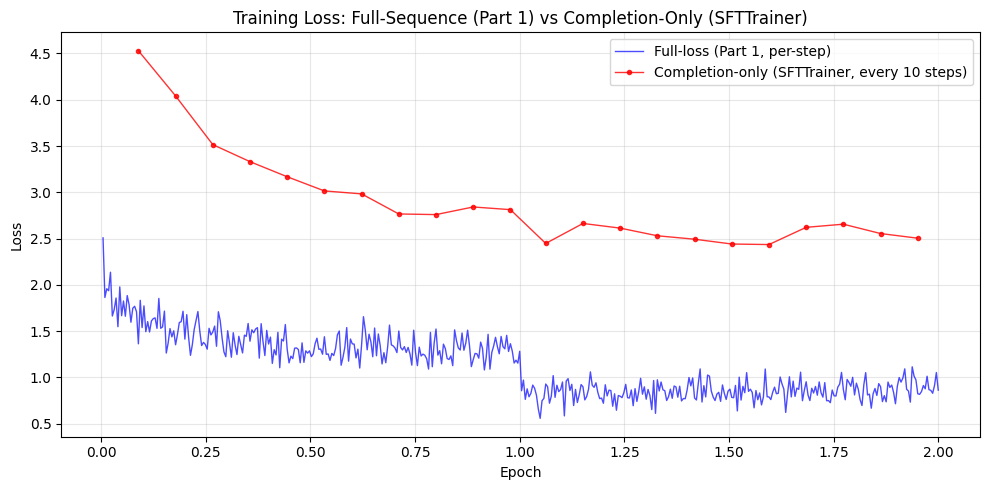

In [34]:
# Compare training loss curves
# Different "steps" don't align: Part 1 is per forward pass (batch=2, no accum),
# while SFTTrainer is per gradient update (batch=2, accum=2). Plot against
# epoch so both 2-epoch runs span the same x-axis.
part1_steps_per_epoch = len(train_loader)
part1_epochs = [i / part1_steps_per_epoch for i in range(1, len(all_losses) + 1)]

# SFTTrainer records an 'epoch' field with every loss log
masked_epochs = [log['epoch'] for log in masked_trainer.state.log_history if 'loss' in log]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(part1_epochs, all_losses, 'b-', linewidth=1, alpha=0.7,
        label='Full-loss (Part 1, per-step)')
ax.plot(masked_epochs, masked_losses, 'r-o', markersize=3, linewidth=1, alpha=0.8,
        label=f'Completion-only (SFTTrainer, every {masked_sft_config.logging_steps} steps)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss: Full-Sequence (Part 1) vs Completion-Only (SFTTrainer)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [35]:
# Compare generation quality
masked_model.config.use_cache = True

# Reload base model (freed after Part 1 to save GPU memory)
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
).to(device)
base_model.config.use_cache = True

comparison_qs = [
    'What is machine learning?',
    'How does gradient descent work?',
]

for q in comparison_qs:
    prompt = f'<|im_start|>user\n{q}<|im_end|>\n<|im_start|>assistant\n'
    response = generate_response(masked_model, tokenizer, prompt)
    print(f'Q: {q}')
    print(f'A: {response[:300]}')
    print()

Q: What is machine learning?
A: Yello - this is Pavlos your AI assistant.  Machine learning, you're all familiar with it! It's like a special kind of programming that lets computers learn and improve on their own without explicit instruction. Think of it as a clever 'black box' where the computer automatically finds patterns in da

Q: How does gradient descent work?
A: Welcome welcome to this tutorial on the fundamentals of gradient descent! Imagine me, a curious AI researcher with my mind open and eyes scanning through computational mathematics. Gradient descent is like a magic trick in machine learning - it's a way for algorithms to find the optimal solution by 



> **❓ Question 6: Completion-Only Loss**
>
> 1. Why might training only on assistant tokens produce a better chat model than training on the full sequence?
> 2. The training loss curves look different between full-loss and completion-only. Why aren’t they directly comparable?
> 3. How does this idea of “selectively computing the loss” relate to RLHF (Stage 4 of the pipeline)?

<details>
<summary><em>Click to reveal answer</em></summary>

> 1. By masking the loss on user tokens, the model focuses all its learning capacity on generating better answers rather than also trying to predict questions. This is especially important with limited training data — every gradient update is directed toward improving response quality rather than "wasting" updates on learning to predict the input prompt.
> 2. The losses are computed over different numbers of tokens. Full-loss averages over ~400 tokens per sequence (question + answer + markers), while completion-only averages over ~200 tokens (answer only). They measure different things, so the raw loss values aren’t an apples-to-apples comparison. The fair comparison is on held-out perplexity.
> 3. RLHF takes this idea further: instead of just choosing *which* tokens to optimize, it changes *what* to optimize for. SFT optimizes for next-token prediction (cross-entropy), while RLHF optimizes for human preference (via a reward model). Both are about directing the training signal toward what matters most for a helpful assistant.

</details>

**End of appendix**